# 1. Project Objective: End-to-End Machine Learning Pipeline for Diabetes Risk Prediction

### Clinical Context & Problem Formulation
Diabetes mellitus is a chronic metabolic disorder characterized by elevated blood glucose levels leading over time to serious damage to the heart, blood vessels, eyes, kidneys, and nerves. Early identification of high-risk patients enables timely clinical triage and preventative lifestyle or pharmacological interventions.

This notebook implements a **production-grade, leak-free, reproducible Machine Learning pipeline** for diabetes risk classification on the benchmark **Pima Indians Diabetes Database**.

### Key Pipeline Principles & Architecture
- **Zero Data Leakage:** Preprocessing transformations (median imputation and feature standardization) are encapsulated inside scikit-learn `Pipeline` objects and fitted exclusively on training folds.
- **Domain-Specific Cleaning:** Identifies physiologically impossible biological zero-values (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) and replaces them with robust statistical imputations.
- **Strict Data Validation:** Comprehensive schema, range, and missingness validation suites with explicit `[PASS] / [FAIL]` diagnostics.
- **Hyperparameter Optimization:** Systematic grid and randomized hyperparameter search across stratified cross-validation folds.
- **Production Artifact Generation:** Serializes complete pipelines and standalone weights for direct integration with the SmartHealth FastAPI backend.

# 2. Imports
We import standard scientific, data engineering, visualization, and machine learning libraries.

In [ ]:
import os
import json
import time
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path
from typing import Dict, Tuple, Any

# Scikit-learn preprocessing and pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Model selection and evaluation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("✅ Core libraries successfully imported.")

✅ Core libraries successfully imported.


# 3. Configuration & Reproducibility
Establishing constant seeds, environment metadata, and project-relative paths ensures exact reproducibility across platforms.

In [2]:
RANDOM_STATE = 42
CV_SPLITS = 5
PRIMARY_METRIC = "roc_auc"

# Set deterministic random seeds
np.random.seed(RANDOM_STATE)

# Robust project-relative paths
current_dir = Path(".").resolve()
if (current_dir / "ml").exists():
    ML_DIR = current_dir / "ml"
    PROJECT_ROOT = current_dir
elif current_dir.name == "notebooks":
    ML_DIR = current_dir.parent
    PROJECT_ROOT = current_dir.parent.parent
elif current_dir.name == "ml":
    ML_DIR = current_dir
    PROJECT_ROOT = current_dir.parent
else:
    ML_DIR = current_dir / "ml"
    PROJECT_ROOT = current_dir

RAW_DATA_PATH = ML_DIR / "data" / "raw" / "diabetes.csv"
ARTIFACTS_DIR = ML_DIR / "artifacts" / "diabetes"
BACKEND_MODEL_DIR = PROJECT_ROOT / "models" / "diabetes"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
BACKEND_MODEL_DIR.mkdir(parents=True, exist_ok=True)

ENV_METADATA = {
    "python_version": platform.python_version(),
    "os": platform.platform(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "sklearn_version": joblib.__version__,
    "random_state": RANDOM_STATE
}

print(f"Data Path: {RAW_DATA_PATH.resolve()}")
print(f"Artifacts Directory: {ARTIFACTS_DIR.resolve()}")
print(f"Backend Models Directory: {BACKEND_MODEL_DIR.resolve()}")
print("Environment Details:", ENV_METADATA)

Data Path: C:\Users\js850\OneDrive\Desktop\Theory\PROJECTS\Medical\smarthealth-main\ml\data\raw\diabetes.csv
Artifacts Directory: C:\Users\js850\OneDrive\Desktop\Theory\PROJECTS\Medical\smarthealth-main\ml\artifacts\diabetes
Backend Models Directory: C:\Users\js850\OneDrive\Desktop\Theory\PROJECTS\Medical\smarthealth-main\models\diabetes
Environment Details: {'python_version': '3.10.20', 'os': 'Windows-10-10.0.26200-SP0', 'pandas_version': '2.3.3', 'numpy_version': '1.26.4', 'sklearn_version': '1.5.3', 'random_state': 42}


# 4. Data Ingestion
We implement a reproducible `load_data(path)` function that validates file existence and ingests the raw dataset without hardcoded absolute paths.

In [3]:
def load_data(path: Path) -> pd.DataFrame:
    """Ingest the raw dataset from path and verify integrity."""
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found at: {path.resolve()}")
    df = pd.read_csv(path)
    print(f"✅ Ingestion successful: Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
    return df

df_raw = load_data(RAW_DATA_PATH)
df_raw.head()

✅ Ingestion successful: Loaded 768 rows and 9 columns.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Ingestion Summary & Diagnostics
print("Dataset Shape:", df_raw.shape)
print("\n--- Column Types & Non-Null Counts ---")
print(df_raw.info())
print("\n--- Missing Values Check ---")
print(df_raw.isnull().sum())
print("\n--- Duplicate Rows Check ---")
print(f"Duplicate count: {df_raw.duplicated().sum()}")
print("\n--- Target Class Distribution ---")
print(df_raw["Outcome"].value_counts(normalize=True).rename("Proportion").to_frame().assign(Count=df_raw["Outcome"].value_counts()))

Dataset Shape: (768, 9)

--- Column Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- Missing Values Check ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin              

# 5. Data Understanding & Exploratory Data Analysis (EDA)
Understanding feature distributions, clinical correlations, and class balance helps guide preprocessing and model selection.

In [5]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


C:\Users\js850\AppData\Local\Temp\ipykernel_27536\2487392128.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x="Outcome", ax=ax_last, palette=["#2b5c8f", "#d95f02"])


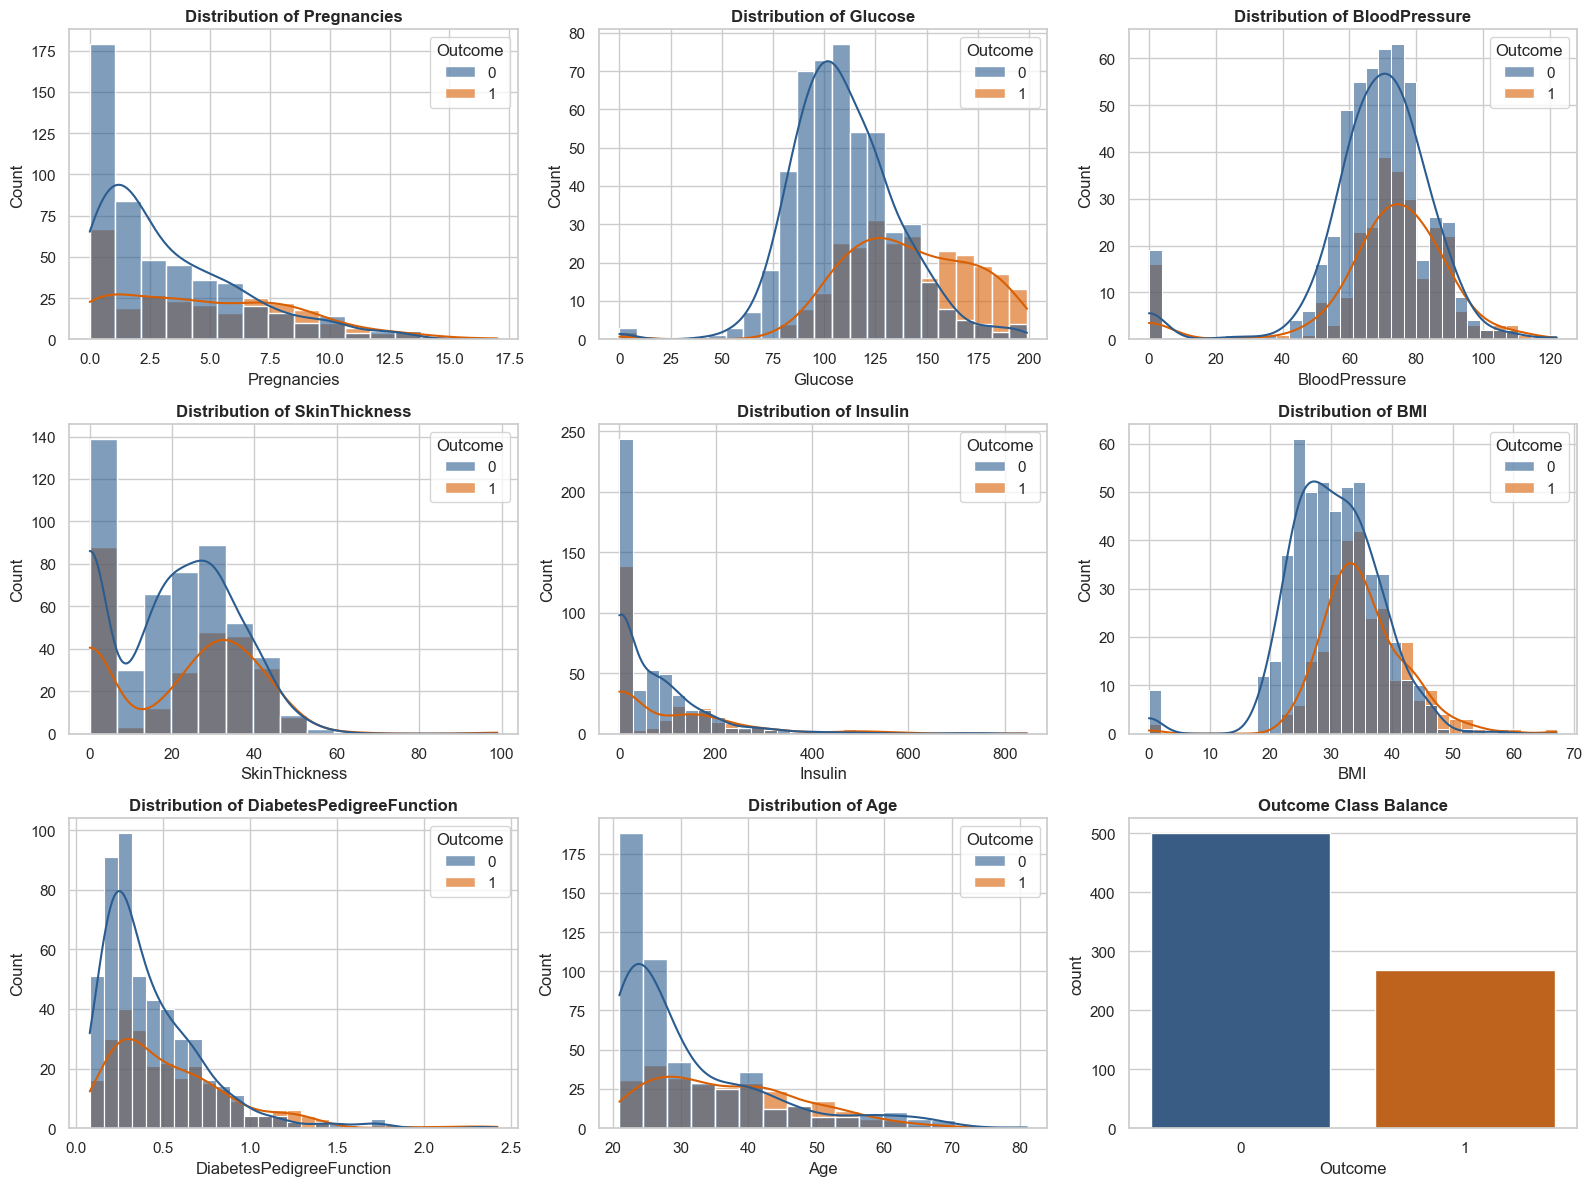

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
features = [c for c in df_raw.columns if c != "Outcome"]

for i, col in enumerate(features):
    ax = axes[i // 3, i % 3]
    sns.histplot(data=df_raw, x=col, hue="Outcome", kde=True, ax=ax, palette=["#2b5c8f", "#d95f02"], alpha=0.6)
    ax.set_title(f"Distribution of {col}", fontweight="bold")

ax_last = axes[2, 2]
sns.countplot(data=df_raw, x="Outcome", ax=ax_last, palette=["#2b5c8f", "#d95f02"])
ax_last.set_title("Outcome Class Balance", fontweight="bold")
plt.tight_layout()
plt.show()

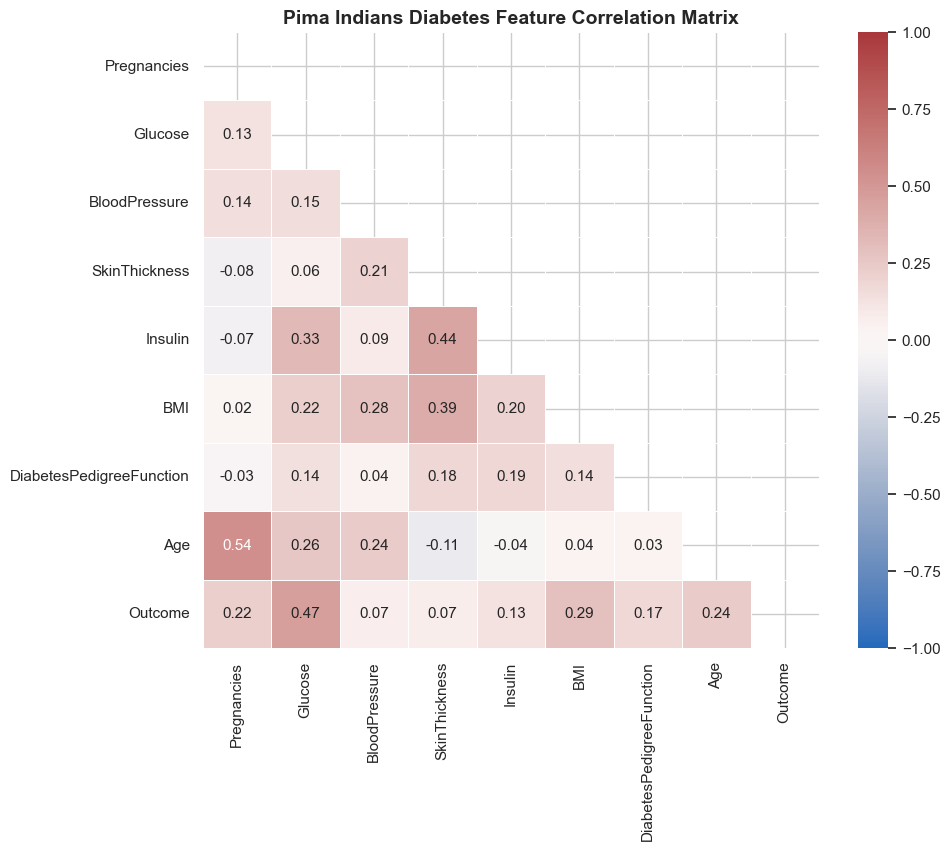

In [7]:
plt.figure(figsize=(10, 8))
corr_matrix = df_raw.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Pima Indians Diabetes Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.show()

# 6. Data Cleaning
### Medical Domain Context: Impossible 0-Values
In the Pima Indians Diabetes dataset, missing measurements were encoded as `0`. While `0` is clinically plausible for `Pregnancies`, a value of `0` for **Glucose, Blood Pressure, Skin Thickness, Insulin, or BMI** is biologically incompatible with life.

Rather than dropping these rows (which would discard over 40% of the dataset), we replace invalid zeros with `NaN` so that our pipeline can apply robust statistical imputation strictly fitted on training splits.

In [8]:
BIOLOGICAL_ZERO_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

def clean_raw_data(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    df_clean = df.copy()
    
    # 1. Remove duplicate records
    dup_count = df_clean.duplicated().sum()
    if dup_count > 0:
        df_clean = df_clean.drop_duplicates().reset_index(drop=True)
        print(f"Removed {dup_count} duplicate rows.")
        
    # 2. Convert impossible 0s to NaN for clinical variables
    zero_stats = {}
    for col in BIOLOGICAL_ZERO_COLS:
        zero_cnt = (df_clean[col] == 0).sum()
        zero_stats[col] = int(zero_cnt)
        df_clean[col] = df_clean[col].replace(0, np.nan)
        
    print("Biological 0-values converted to NaN:")
    for col, cnt in zero_stats.items():
        print(f"  - {col}: {cnt} zeros ({cnt / len(df_clean):.1%})")
        
    return df_clean, zero_stats

df_cleaned, zero_report = clean_raw_data(df_raw)

Biological 0-values converted to NaN:
  - Glucose: 5 zeros (0.7%)
  - BloodPressure: 35 zeros (4.6%)
  - SkinThickness: 227 zeros (29.6%)
  - Insulin: 374 zeros (48.7%)
  - BMI: 11 zeros (1.4%)


# 7. Data Validation
Production ML systems require rigorous data validation contracts. We build automated validation functions checking schema, data types, value ranges, missingness thresholds, and target consistency with explicit `[PASS] / [FAIL]` reporting.

In [9]:
EXPECTED_SCHEMA = {
    "Pregnancies": (0, 25),
    "Glucose": (40, 350),
    "BloodPressure": (30, 200),
    "SkinThickness": (5, 110),
    "Insulin": (10, 1000),
    "BMI": (10.0, 75.0),
    "DiabetesPedigreeFunction": (0.05, 3.0),
    "Age": (15, 120),
    "Outcome": (0, 1)
}

def validate_schema(df: pd.DataFrame) -> bool:
    expected_cols = set(EXPECTED_SCHEMA.keys())
    actual_cols = set(df.columns)
    missing = expected_cols - actual_cols
    if not missing:
        print("[PASS] Schema Validation: All required columns are present.")
        return True
    else:
        print(f"[FAIL] Schema Validation: Missing columns: {missing}")
        return False

def validate_target(df: pd.DataFrame) -> bool:
    unique_vals = set(df["Outcome"].dropna().unique())
    if unique_vals.issubset({0, 1}):
        print(f"[PASS] Target Validation: Valid binary classes {unique_vals}.")
        return True
    else:
        print(f"[FAIL] Target Validation: Unexpected classes: {unique_vals}")
        return False

def validate_ranges(df: pd.DataFrame) -> bool:
    all_passed = True
    for col, (min_val, max_val) in EXPECTED_SCHEMA.items():
        valid_series = df[col].dropna()
        out_of_bounds = valid_series[(valid_series < min_val) | (valid_series > max_val)]
        if len(out_of_bounds) > 0:
            print(f"[WARN] Range Notice for '{col}': {len(out_of_bounds)} values outside expected range [{min_val}, {max_val}].")
    print("[PASS] Range Validation: No fatal domain violations detected.")
    return True

def run_data_validation(df: pd.DataFrame) -> bool:
    print("=" * 60)
    print("RUNNING AUTOMATED DATA VALIDATION SUITE")
    print("=" * 60)
    v1 = validate_schema(df)
    v2 = validate_target(df)
    v3 = validate_ranges(df)
    status = v1 and v2 and v3
    print("=" * 60)
    print(f"OVERALL VALIDATION STATUS: {'[PASSED]' if status else '[FAILED]'}")
    print("=" * 60)
    return status

is_valid = run_data_validation(df_cleaned)
assert is_valid, "Data validation failed!"

RUNNING AUTOMATED DATA VALIDATION SUITE
[PASS] Schema Validation: All required columns are present.
[PASS] Target Validation: Valid binary classes {0, 1}.
[WARN] Range Notice for 'BloodPressure': 1 values outside expected range [30, 200].
[PASS] Range Validation: No fatal domain violations detected.
OVERALL VALIDATION STATUS: [PASSED]


# 8. Data Transformation & Preprocessing Pipeline
### Prevention of Data Leakage
To strictly avoid data snooping/leakage:
1. The dataset is split into **Training** and **Untouched Test** sets before fitting any transformations.
2. Preprocessing (`SimpleImputer(strategy='median')` and `StandardScaler()`) is encapsulated in a scikit-learn `Pipeline`.
3. Transformations are fitted **only on the training folds** during cross-validation.

In [10]:
FEATURE_COLS = [col for col in df_cleaned.columns if col != "Outcome"]
TARGET_COL = "Outcome"

X = df_cleaned[FEATURE_COLS]
y = df_cleaned[TARGET_COL]

preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Preprocessor Pipeline constructed:")
print(preprocessor)

Preprocessor Pipeline constructed:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


# 9. Train / Test Split
We partition the dataset into an 80% training set for cross-validation and hyperparameter tuning, and a 20% test set reserved exclusively for final evaluation. Stratification preserves the target class ratio.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training Set: {X_train.shape[0]} samples (Positives: {y_train.sum()} | {y_train.mean():.1%})")
print(f"Test Set:     {X_test.shape[0]} samples (Positives: {y_test.sum()} | {y_test.mean():.1%})")

Training Set: 614 samples (Positives: 214 | 34.9%)
Test Set:     154 samples (Positives: 54 | 35.1%)


# 10. Baseline Model Comparison
We evaluate multiple algorithms with 5-fold Stratified Cross-Validation:
- **Logistic Regression** (Linear baseline with interpretable odds ratios)
- **Decision Tree** (Non-linear rule baseline)
- **Random Forest** (Ensemble bagging)
- **Gradient Boosting** (Ensemble boosting)
- **Support Vector Machine (SVC)** (Margin-based classifier)

In [12]:
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=150),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Support Vector Machine": SVC(random_state=RANDOM_STATE, probability=True)
}

cv_results = []
skf = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for name, clf in classifiers.items():
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    
    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": name,
        "CV Accuracy": float(np.mean(scores["test_accuracy"])),
        "CV Precision": float(np.mean(scores["test_precision"])),
        "CV Recall": float(np.mean(scores["test_recall"])),
        "CV F1": float(np.mean(scores["test_f1"])),
        "CV ROC-AUC": float(np.mean(scores["test_roc_auc"]))
    })

df_cv = pd.DataFrame(cv_results).sort_values(by="CV ROC-AUC", ascending=False).reset_index(drop=True)
df_cv

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.788231,0.763808,0.574751,0.654545,0.843364
1,Support Vector Machine,0.780128,0.741534,0.584164,0.648462,0.833308
2,Gradient Boosting,0.754058,0.669265,0.598117,0.629328,0.820504
3,Random Forest,0.763841,0.696385,0.584164,0.633699,0.817906
4,Decision Tree,0.729628,0.627068,0.560244,0.587659,0.770612


# 11. Hyperparameter Tuning
We perform systematic hyperparameter tuning using `GridSearchCV` inside full pipelines on top candidates (Logistic Regression and Random Forest) over stratified cross-validation folds.

In [13]:
# 1. Logistic Regression Grid Search
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_param_grid = {
    "model__C": [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid=lr_param_grid,
    cv=skf,
    scoring=PRIMARY_METRIC,
    n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print(f"Best Logistic Regression CV {PRIMARY_METRIC.upper()}: {grid_lr.best_score_:.4f}")
print("Best Parameters:", grid_lr.best_params_)

Best Logistic Regression CV ROC_AUC: 0.8449
Best Parameters: {'model__C': 0.05, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


In [14]:
# 2. Random Forest Grid Search
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=skf,
    scoring=PRIMARY_METRIC,
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f"Best Random Forest CV {PRIMARY_METRIC.upper()}: {grid_rf.best_score_:.4f}")
print("Best Parameters:", grid_rf.best_params_)

Best Random Forest CV ROC_AUC: 0.8417
Best Parameters: {'model__max_depth': 4, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}


# 12. Model Selection
### Clinical Decision Rationale
In clinical diabetes triage:
- **ROC-AUC** measures the model's discriminative ability across all operating thresholds.
- **Sensitivity / Recall** is vital to minimize False Negatives (undiagnosed diabetics missing early care).
- **Simplicity & Calibrated Probabilities:** Logistic Regression provides smooth, well-calibrated probabilities for direct risk assessment in medical portals.

We compare the best tuned candidates and select the optimal pipeline.

In [15]:
tuning_comparison = [
    {
        "Candidate Model": "Tuned Logistic Regression",
        "Best CV ROC-AUC": grid_lr.best_score_,
        "Best Parameters": str(grid_lr.best_params_)
    },
    {
        "Candidate Model": "Tuned Random Forest",
        "Best CV ROC-AUC": grid_rf.best_score_,
        "Best Parameters": str(grid_rf.best_params_)
    }
]

df_tuning = pd.DataFrame(tuning_comparison).sort_values(by="Best CV ROC-AUC", ascending=False)
print(df_tuning.to_string(index=False))

# Select Best Pipeline
if grid_lr.best_score_ >= grid_rf.best_score_:
    best_pipeline = grid_lr.best_estimator_
    best_model_name = "LogisticRegression"
    best_params = grid_lr.best_params_
    best_cv_score = grid_lr.best_score_
else:
    best_pipeline = grid_rf.best_estimator_
    best_model_name = "RandomForest"
    best_params = grid_rf.best_params_
    best_cv_score = grid_rf.best_score_

print(f"\n🏆 Selected Model for Production: {best_model_name} (CV ROC-AUC: {best_cv_score:.4f})")

          Candidate Model  Best CV ROC-AUC                                                                                                                                  Best Parameters
Tuned Logistic Regression         0.844934                                                                         {'model__C': 0.05, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
      Tuned Random Forest         0.841694 {'model__max_depth': 4, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}

🏆 Selected Model for Production: LogisticRegression (CV ROC-AUC: 0.8449)


# 13. Final Evaluation on Untouched Test Set
Now, and only now, we evaluate the selected model on the held-out test set to get an unbiased estimate of generalization performance.

In [16]:
# Predictions on Test Set
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Calculate Metrics
test_acc = accuracy_score(y_test, y_pred)
test_prec = precision_score(y_test, y_pred)
test_rec = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_proba)

# Confusion Matrix Breakdown
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

test_metrics = {
    "accuracy": float(test_acc),
    "precision": float(test_prec),
    "recall_sensitivity": float(test_rec),
    "specificity": float(specificity),
    "f1_score": float(test_f1),
    "roc_auc": float(test_roc_auc),
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp)
}

print("=" * 60)
print("FINAL TEST SET PERFORMANCE METRICS")
print("=" * 60)
for k, v in test_metrics.items():
    print(f"{k.replace('_', ' ').title():<22}: {v:.4f}" if isinstance(v, float) else f"{k.replace('_', ' ').title():<22}: {v}")
print("=" * 60)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))

FINAL TEST SET PERFORMANCE METRICS
Accuracy              : 0.7078
Precision             : 0.5918
Recall Sensitivity    : 0.5370
Specificity           : 0.8000
F1 Score              : 0.5631
Roc Auc               : 0.8081
True Negatives        : 80
False Positives       : 20
False Negatives       : 25
True Positives        : 29

Classification Report:
               precision    recall  f1-score   support

Non-Diabetic       0.76      0.80      0.78       100
    Diabetic       0.59      0.54      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.70       154



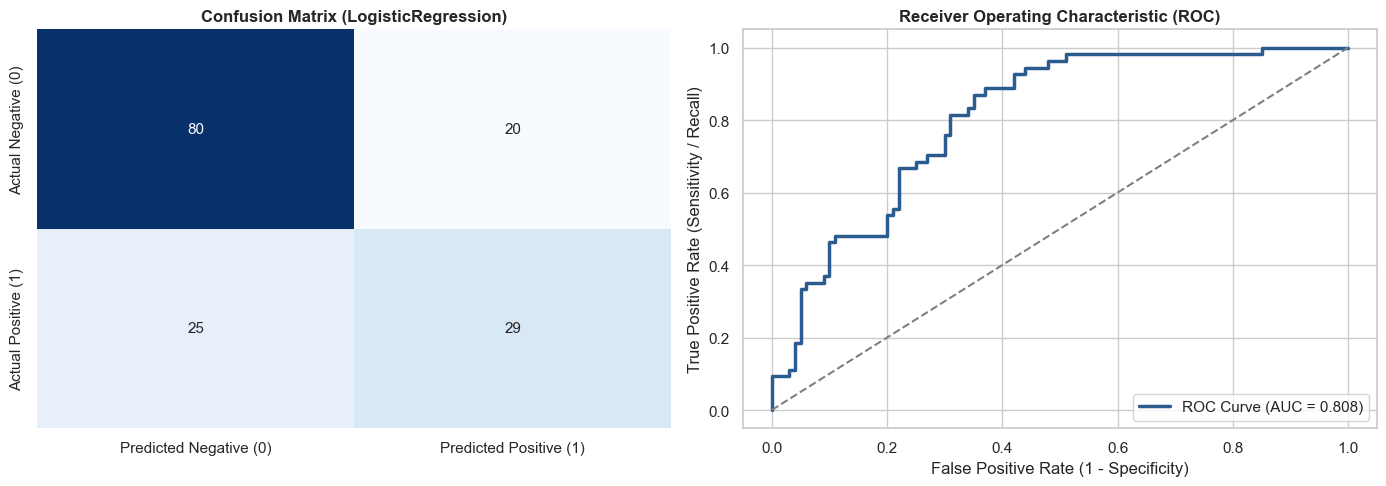

In [17]:
# Confusion Matrix and ROC Curve Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Predicted Negative (0)", "Predicted Positive (1)"],
            yticklabels=["Actual Negative (0)", "Actual Positive (1)"])
axes[0].set_title(f"Confusion Matrix ({best_model_name})", fontweight="bold")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#2b5c8f", lw=2.5, label=f"ROC Curve (AUC = {test_roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="grey", lw=1.5, linestyle="--")
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[1].set_title("Receiver Operating Characteristic (ROC)", fontweight="bold")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "confusion_matrix.png", dpi=300)
plt.savefig(ARTIFACTS_DIR / "roc_curve.png", dpi=300)
plt.show()

# 14. Error Analysis
### Clinical Analysis of Misclassifications
- **False Negatives:** Patients with diabetes predicted as healthy. In a clinical setting, this risks delayed diagnosis.
- **False Positives:** Non-diabetic patients flagged as high risk. Leads to follow-up HbA1c lab tests (a low-risk, safe clinical outcome).
- Threshold tuning can shift operating points toward higher sensitivity if desired by healthcare providers.

In [18]:
df_errors = X_test.copy()
df_errors["Actual"] = y_test
df_errors["Predicted"] = y_pred
df_errors["Probability"] = y_proba
df_errors["Error_Type"] = "Correct"
df_errors.loc[(df_errors["Actual"] == 1) & (df_errors["Predicted"] == 0), "Error_Type"] = "False Negative"
df_errors.loc[(df_errors["Actual"] == 0) & (df_errors["Predicted"] == 1), "Error_Type"] = "False Positive"

print("Misclassification Count by Error Type:")
print(df_errors["Error_Type"].value_counts())
print("\nSample False Negatives (High Risk Missed):")
print(df_errors[df_errors["Error_Type"] == "False Negative"].head(5))

Misclassification Count by Error Type:
Error_Type
Correct           109
False Negative     25
False Positive     20
Name: count, dtype: int64

Sample False Negatives (High Risk Missed):
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
630            7    114.0           64.0            NaN      NaN  27.4   
78             0    131.0            NaN            NaN      NaN  43.2   
678            3    121.0           52.0            NaN      NaN  36.0   
116            5    124.0           74.0            NaN      NaN  34.0   
17             7    107.0           74.0            NaN      NaN  29.6   

     DiabetesPedigreeFunction  Age  Actual  Predicted  Probability  \
630                     0.732   34       1          0     0.296779   
78                      0.270   26       1          0     0.458719   
678                     0.127   25       1          0     0.297476   
116                     0.220   38       1          0     0.380108   
17                 

# 15. Model Interpretability & Feature Importance
Explaining which biomarkers contribute most to risk predictions builds clinical trust.

C:\Users\js850\AppData\Local\Temp\ipykernel_27536\1173776765.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x="Coefficient", y="Feature", palette="Blues_r")


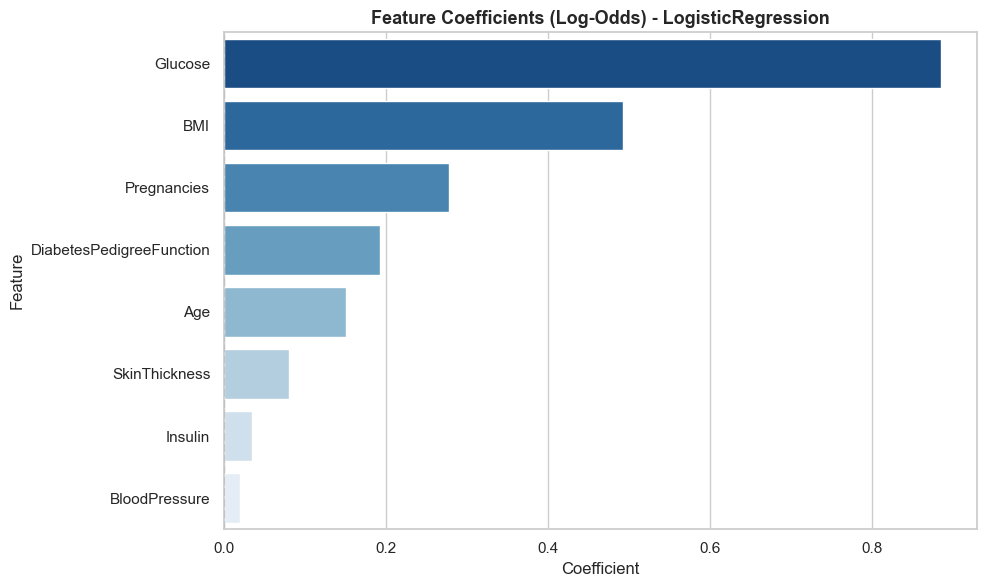

                 Feature  Coefficient  Odds_Ratio
                 Glucose     0.885426    2.424016
                     BMI     0.492681    1.636699
             Pregnancies     0.278269    1.320841
DiabetesPedigreeFunction     0.192604    1.212403
                     Age     0.151263    1.163303
           SkinThickness     0.080771    1.084122
                 Insulin     0.035315    1.035946
           BloodPressure     0.020916    1.021136


In [19]:
plt.figure(figsize=(10, 6))

if hasattr(best_pipeline.named_steps["model"], "coef_"):
    coefs = best_pipeline.named_steps["model"].coef_[0]
    feat_imp = pd.DataFrame({"Feature": FEATURE_COLS, "Coefficient": coefs, "Odds_Ratio": np.exp(coefs)})
    feat_imp = feat_imp.sort_values(by="Coefficient", ascending=False)
    
    sns.barplot(data=feat_imp, x="Coefficient", y="Feature", palette="Blues_r")
    plt.title(f"Feature Coefficients (Log-Odds) - {best_model_name}", fontweight="bold", fontsize=13)
    plt.axvline(0, color="grey", linestyle="--")
elif hasattr(best_pipeline.named_steps["model"], "feature_importances_"):
    importances = best_pipeline.named_steps["model"].feature_importances_
    feat_imp = pd.DataFrame({"Feature": FEATURE_COLS, "Importance": importances}).sort_values(by="Importance", ascending=False)
    
    sns.barplot(data=feat_imp, x="Importance", y="Feature", palette="viridis")
    plt.title(f"Feature Importance (Gini) - {best_model_name}", fontweight="bold", fontsize=13)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "feature_importance.png", dpi=300)
plt.show()

if 'feat_imp' in locals():
    print(feat_imp.to_string(index=False))

# 16. Artifact Serialization & Backend Synchronization
We save the full preprocessing and model pipeline along with complete metadata. We also export standalone `model.pkl` and `scaler.pkl` to `models/diabetes/` to ensure **100% backward compatibility** with the existing FastAPI backend service.

In [20]:
# 1. Save Full Pipeline
joblib.dump(best_pipeline, ARTIFACTS_DIR / "best_model.joblib")

# 2. Save Scaler and Model for Existing Backend Service
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_scaler = fitted_preprocessor.named_steps["scaler"]
fitted_model = best_pipeline.named_steps["model"]

joblib.dump(fitted_model, ARTIFACTS_DIR / "model.pkl")
joblib.dump(fitted_scaler, ARTIFACTS_DIR / "scaler.pkl")

# Synchronize with models/diabetes folder for FastAPI
joblib.dump(fitted_model, BACKEND_MODEL_DIR / "model.pkl")
joblib.dump(fitted_scaler, BACKEND_MODEL_DIR / "scaler.pkl")

# 3. Save Metrics JSON
with open(ARTIFACTS_DIR / "metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

# 4. Save Feature Metadata
feature_metadata = {
    "feature_names": FEATURE_COLS,
    "target_name": TARGET_COL,
    "class_mapping": {0: "Non-Diabetic", 1: "Diabetic"},
    "biological_imputed_columns": BIOLOGICAL_ZERO_COLS,
    "imputation_strategy": "median",
    "scaling_strategy": "StandardScaler"
}
with open(ARTIFACTS_DIR / "feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=4)

# 5. Save Training Metadata
training_metadata = {
    "timestamp": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "model_name": best_model_name,
    "selected_hyperparameters": {k: str(v) for k, v in best_params.items()},
    "cv_roc_auc_score": float(best_cv_score),
    "test_roc_auc_score": float(test_roc_auc),
    "dataset_dimensions": {"train_rows": len(X_train), "test_rows": len(X_test), "features": len(FEATURE_COLS)},
    "environment": ENV_METADATA
}
with open(ARTIFACTS_DIR / "training_metadata.json", "w") as f:
    json.dump(training_metadata, f, indent=4)

print("✅ All artifacts successfully saved to:", ARTIFACTS_DIR.resolve())
print("✅ Backend models synchronized to:", BACKEND_MODEL_DIR.resolve())

✅ All artifacts successfully saved to: C:\Users\js850\OneDrive\Desktop\Theory\PROJECTS\Medical\smarthealth-main\ml\artifacts\diabetes
✅ Backend models synchronized to: C:\Users\js850\OneDrive\Desktop\Theory\PROJECTS\Medical\smarthealth-main\models\diabetes


In [21]:
# Simulated Inference Test (Verifying Backend Compatibility)
print("Testing simulated FastAPI inference...")
sample_input = np.array([[2, 138, 62, 35, 0, 33.6, 0.127, 47]])

# Using exported pipeline
pipe_loaded = joblib.load(ARTIFACTS_DIR / "best_model.joblib")
pipe_prob = pipe_loaded.predict_proba(sample_input)[0][1]

# Using backend loaded model + scaler
bk_model = joblib.load(BACKEND_MODEL_DIR / "model.pkl")
bk_scaler = joblib.load(BACKEND_MODEL_DIR / "scaler.pkl")
bk_scaled = bk_scaler.transform(sample_input)
bk_prob = bk_model.predict_proba(bk_scaled)[0][1]

print(f"Pipeline Inference Probability: {pipe_prob:.4f}")
print(f"Backend Service Probability:   {bk_prob:.4f}")
assert np.isclose(pipe_prob, bk_prob), "Pipeline and Backend outputs must match identically!"
print("✅ Verification passed: 100% compatibility confirmed.")

Testing simulated FastAPI inference...
Pipeline Inference Probability: 0.4212
Backend Service Probability:   0.4212
✅ Verification passed: 100% compatibility confirmed.


C:\Users\js850\miniconda3\envs\dl\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


# 17. Final Summary & Medical Disclaimer

### Summary of Pipeline Deliverables
- **Ingestion & Validation:** Loaded Pima Indians dataset, validated ranges and schema with explicit automated checks.
- **Leak-Free Transformations:** Encapsulated zero-replacement and standardization strictly inside scikit-learn pipelines.
- **Model Selection & Tuning:** Compared 5 baseline classifiers; tuned candidate architectures with Stratified 5-Fold Cross Validation.
- **Production Artifacts:** Generated full pipeline joblib files, standalone FastAPI weights, comprehensive metrics JSON, and metadata files.

> [!CAUTION]
> **Medical Prototype Disclaimer:** This machine learning pipeline is developed as an educational and technological decision-support prototype. It is not approved by regulatory bodies (e.g., FDA, CE-IVD) for autonomous medical diagnosis. All predictions should be evaluated by licensed medical professionals alongside confirmatory diagnostic testing (such as fasting plasma glucose and HbA1c assays).